# Picos R

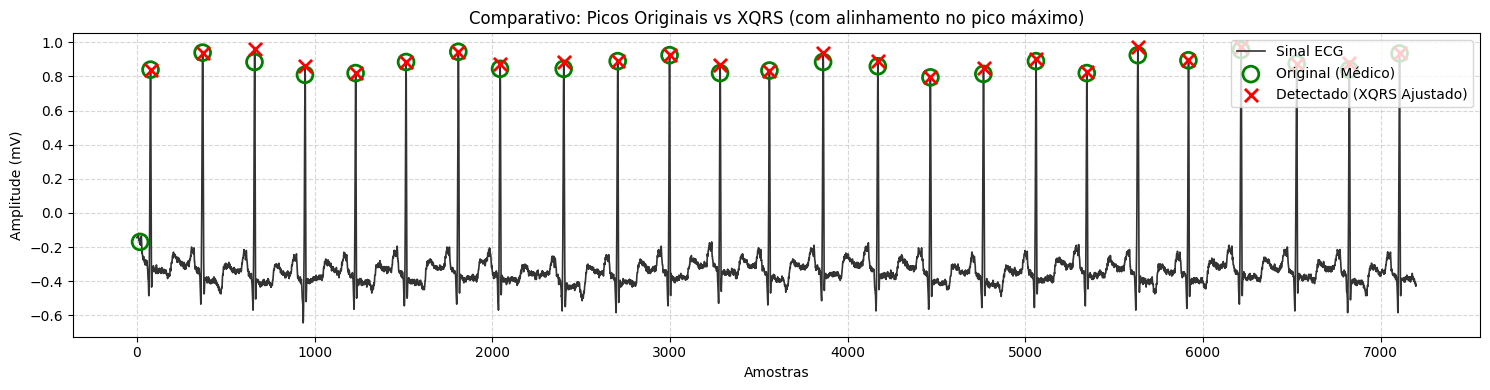

In [5]:
import wfdb
from wfdb import processing
import matplotlib.pyplot as plt
import numpy as np

# 1. Carregar sinal e anotações do MIT-BIH
registro = wfdb.rdrecord('../database/raw/100')
anotacao = wfdb.rdann('../database/raw/100', 'atr')

sinal = registro.p_signal[:, 0]  # Canal 0 (MLII)
fs = registro.fs

# 2. Picos originais anotados pelo médico
picos_originais = anotacao.sample

# 3. Detecção com XQRS
picos_xqrs = processing.xqrs_detect(sig=sinal, fs=fs, verbose=False)

# 4. Refinamento: busca o ponto de amplitude máxima local (+-10 amostras)
JANELA_AJUSTE = 10
picos_ajustados = []
for p in picos_xqrs:
    inicio = max(0, p - JANELA_AJUSTE)
    fim = min(len(sinal), p + JANELA_AJUSTE + 1)
    pico_max = inicio + np.argmax(sinal[inicio:fim])
    picos_ajustados.append(pico_max)

picos_ajustados = np.array(picos_ajustados)

# 5. Recortar primeiros 5 segundos para visualização
amostras_5s = int(20 * fs)
sinal_trecho = sinal[:amostras_5s]

originais_trecho = picos_originais[picos_originais < amostras_5s]
xqrs_trecho = picos_ajustados[picos_ajustados < amostras_5s]

# 6. Plotar comparativo
plt.figure(figsize=(15, 4))
plt.plot(sinal_trecho, label='Sinal ECG', color='#333333', linewidth=1.2)

# Círculo verde = Original do Especialista
plt.scatter(
    originais_trecho,
    sinal_trecho[originais_trecho],
    color='green',
    s=130,
    facecolors='none',
    edgecolors='green',
    linewidth=2,
    label='Original (Médico)',
    zorder=4
)

# X vermelho = Picos XQRS Ajustados ao Topo
plt.scatter(
    xqrs_trecho,
    sinal_trecho[xqrs_trecho],
    color='red',
    marker='x',
    s=90,
    linewidth=2,
    label='Detectado (XQRS Ajustado)',
    zorder=5
)

plt.title('Comparativo: Picos Originais vs XQRS (com alinhamento no pico máximo)')
plt.xlabel('Amostras')
plt.ylabel('Amplitude (mV)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()